<a href="https://colab.research.google.com/github/korgaonkarparth2522-max/CSL701-CSE26_Machine-Learning-Lab/blob/main/Experiment/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Parth Shantaram Korgankar
Roll No: Cs26

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


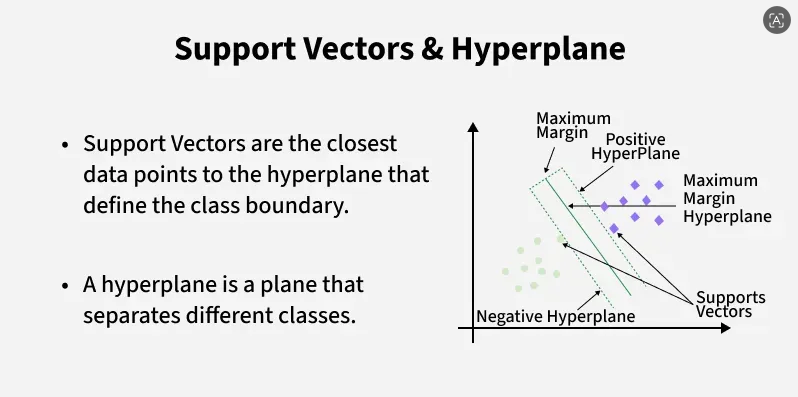
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Iris dataset
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

df = pd.read_csv(url)

# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Task 2: Explore the Dataset

In [2]:
# Task 2: Explore the Dataset

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Display class distribution
print("\nClass Distribution:")
print(df["species"].value_counts())

Dataset Shape: (150, 5)

Column Names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Task 3: Select Features and Target

# Display columns
print("Columns before removing Id:")
print(df.columns)

# Remove Id column if it exists
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

# Select features
X = df.drop("species", axis=1)

# Select target
y = df["species"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Columns before removing Id:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

Feature Shape: (150, 4)
Target Shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
# Task 4: Split and Scale the Data

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("\nScaled training data:")
print(X_train_scaled[:5])

print("\nScaled testing data:")
print(X_test_scaled[:5])


Training data shape: (120, 4)
Testing data shape: (30, 4)

Scaled training data:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]

Scaled testing data:
[[-1.72156775 -0.0995174  -1.40385252 -1.32016847]
 [ 0.30848902 -0.0995174   0.64155823  0.78333648]
 [-1.12449223 -1.45145189 -0.26751321 -0.268416  ]
 [-1.00507713 -1.67677431 -0.26751321 -0.268416  ]
 [-1.72156775  0.35112743 -1.40385252 -1.32016847]]


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
# Task 5: Implement Linear SVM

# Create Linear SVM model
svm_model = SVC(kernel="linear", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Predictions:")
print(y_pred_svm)

SVM Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [7]:
# Task 6: Evaluate SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Create Linear SVM model
svm_model = SVC(kernel="linear")

# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# --------------------------------------------------
# Calculate Accuracy
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:")
print(accuracy)

print("\nSVM Accuracy (%):")
print(accuracy * 100, "%")


# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

SVM Accuracy:
1.0

SVM Accuracy (%):
100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

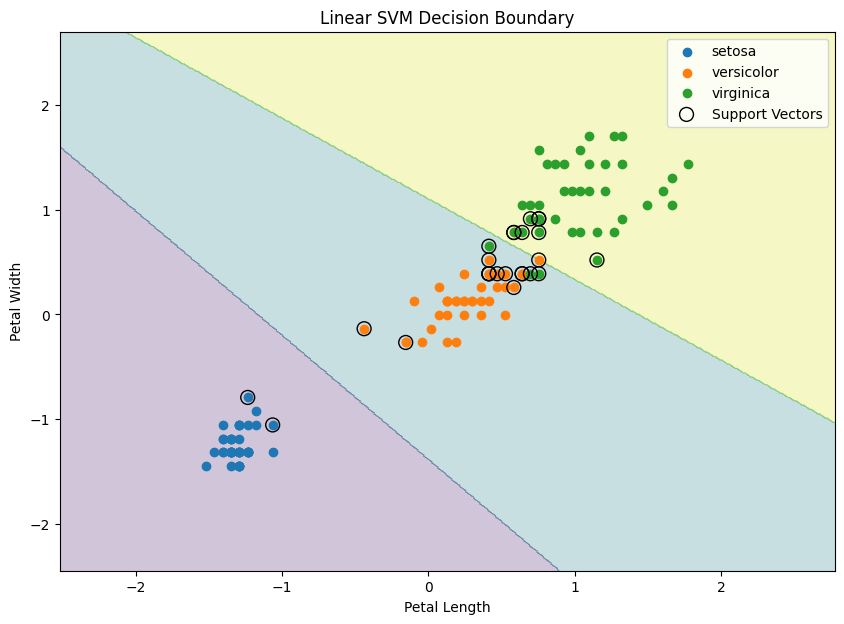

In [8]:
# Task 7: Visualize SVM Decision Boundary

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Select Petal Length and Petal Width
X_2d = df[["petal_length", "petal_width"]]
y_2d = df["species"]

# Split data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the data
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Create Linear SVM
svm_2d = SVC(kernel="linear")

# Train model
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Create grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for grid points
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert class names to numbers
class_names = sorted(y_2d.unique())
Z = np.array([class_names.index(label) for label in Z])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.25)

# Plot data points
for class_name in class_names:
    mask = y_train_2d == class_name

    plt.scatter(
        X_train_2d_scaled[mask.values, 0],
        X_train_2d_scaled[mask.values, 1],
        label=class_name
    )

# Plot support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

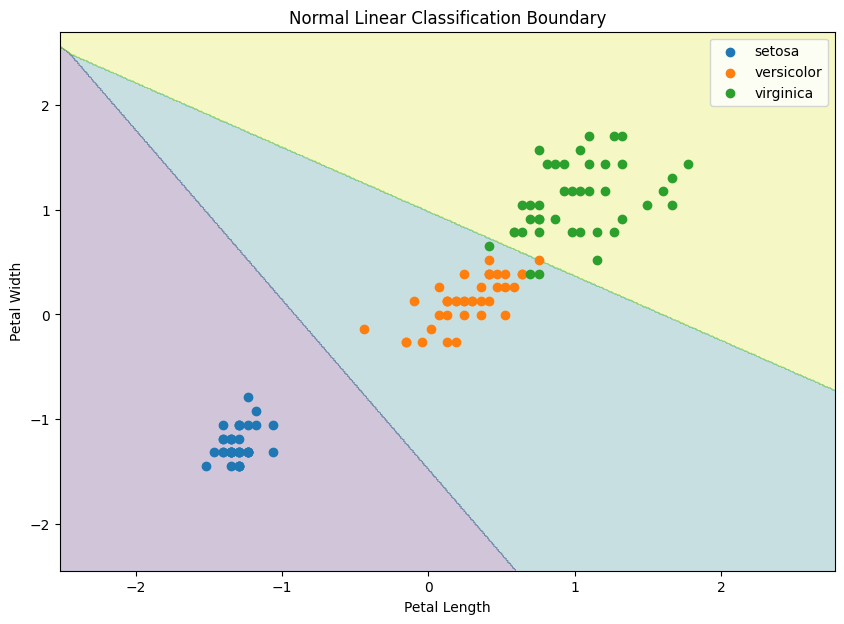

In [9]:
# Task 8: Normal Linear Classification Boundary

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(X_train_2d_scaled, y_train_2d)

# Create grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict grid points
Z = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert class names to numbers
class_names = sorted(y_2d.unique())

Z = np.array([
    class_names.index(label)
    for label in Z
])

Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.25)

# Plot data points
for class_name in class_names:
    mask = y_train_2d == class_name

    plt.scatter(
        X_train_2d_scaled[mask.values, 0],
        X_train_2d_scaled[mask.values, 1],
        label=class_name
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Normal Linear Classification Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

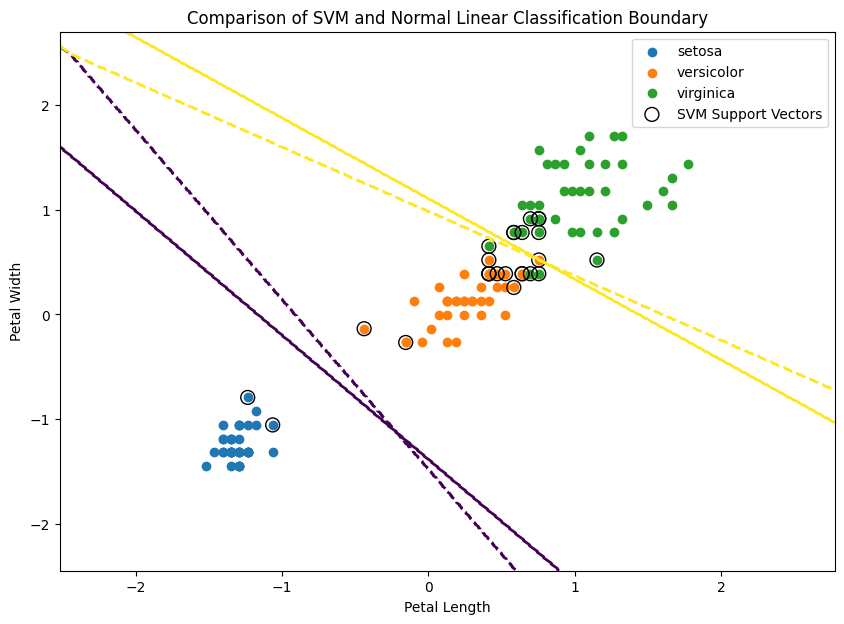

In [10]:
# Task 9: Compare SVM and Normal Linear Boundary

import numpy as np
import matplotlib.pyplot as plt

# Create grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predictions from SVM
Z_svm = svm_2d.predict(grid)

# Predictions from Logistic Regression
Z_logistic = logistic_model.predict(grid)

# Convert class labels to numbers
class_names = sorted(y_2d.unique())

Z_svm = np.array([
    class_names.index(label)
    for label in Z_svm
]).reshape(xx.shape)

Z_logistic = np.array([
    class_names.index(label)
    for label in Z_logistic
]).reshape(xx.shape)

# Plot both boundaries
plt.figure(figsize=(10, 7))

# SVM boundary
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=np.arange(len(class_names) - 1) + 0.5,
    linewidths=2
)

# Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=np.arange(len(class_names) - 1) + 0.5,
    linestyles="dashed",
    linewidths=2
)

# Plot data points
for class_name in class_names:
    mask = y_train_2d == class_name

    plt.scatter(
        X_train_2d_scaled[mask.values, 0],
        X_train_2d_scaled[mask.values, 1],
        label=class_name
    )

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="SVM Support Vectors"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Comparison of SVM and Normal Linear Classification Boundary")
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

SVM Accuracy: 0.9333333333333333
SVM Accuracy (%): 93.33333333333333

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy (%): 93.33333333333333


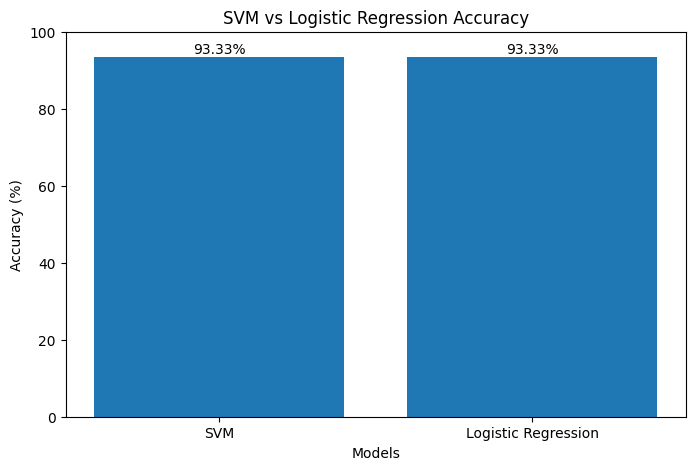


===== SVM CONFUSION MATRIX =====
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


<Figure size 600x500 with 0 Axes>

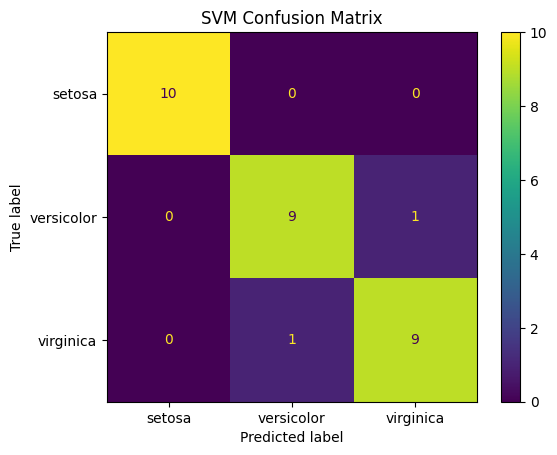


===== LOGISTIC REGRESSION CONFUSION MATRIX =====
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


<Figure size 600x500 with 0 Axes>

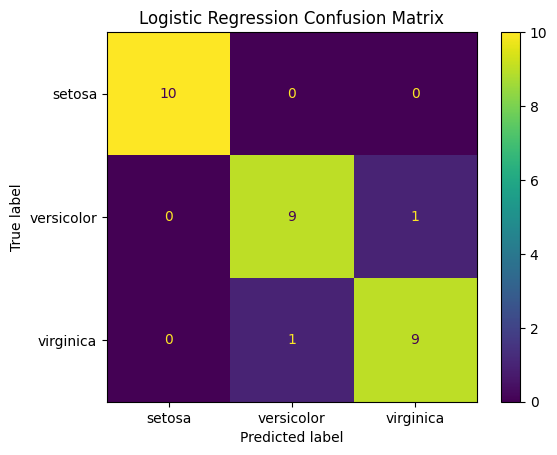


===== SVM CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [12]:
# Task 10: Compare Performance

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------------
# 1. Make predictions
# -----------------------------------

# SVM predictions
y_pred_svm = svm_2d.predict(X_test_2d_scaled)

# Logistic Regression predictions
y_pred_logistic = logistic_model.predict(X_test_2d_scaled)


# -----------------------------------
# 2. Calculate Accuracy
# -----------------------------------

svm_accuracy = accuracy_score(y_test_2d, y_pred_svm)
logistic_accuracy = accuracy_score(y_test_2d, y_pred_logistic)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

print("\nLogistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Accuracy (%):", logistic_accuracy * 100)


# -----------------------------------
# 3. Accuracy Comparison Graph
# -----------------------------------

models = ["SVM", "Logistic Regression"]
accuracies = [
    svm_accuracy * 100,
    logistic_accuracy * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("SVM vs Logistic Regression Accuracy")

plt.ylim(0, 100)

# Show accuracy values on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()


# -----------------------------------
# 4. SVM Confusion Matrix
# -----------------------------------

print("\n===== SVM CONFUSION MATRIX =====")

cm_svm = confusion_matrix(y_test_2d, y_pred_svm)

print(cm_svm)

plt.figure(figsize=(6, 5))

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=class_names
)

disp_svm.plot()

plt.title("SVM Confusion Matrix")
plt.show()


# -----------------------------------
# 5. Logistic Regression
#    Confusion Matrix
# -----------------------------------

print("\n===== LOGISTIC REGRESSION CONFUSION MATRIX =====")

cm_logistic = confusion_matrix(
    y_test_2d,
    y_pred_logistic
)

print(cm_logistic)

plt.figure(figsize=(6, 5))

disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=class_names
)

disp_logistic.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()


# -----------------------------------
# 6. SVM Classification Report
# -----------------------------------

print("\n===== SVM CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_2d,
        y_pred_svm
    )
)


# -----------------------------------
# 7. Logistic Regression
#    Classification Report
# -----------------------------------

print("\n===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_2d,
        y_pred_logistic
    )
)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.